# Streaming in LangGraph

### Problem Statement

Build an **essay-writing workflow using LangGraph** in Python that generates a well-structured essay from a given topic.

The workflow should:

Accept an essay topic from the user.
Generate an outline for the essay.
Write the essay based on the generated outline.
Return the final polished essay.

#### Workflow:

START → Generate Outline → Write Essay → END

In [4]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [5]:
load_dotenv()

True

In [6]:
model = ChatOpenAI(model='gpt-5.4-mini')

In [8]:
class EssayState(TypedDict):
    topic: str
    outlines: str
    essay: str

In [9]:
def generate_outlines(state: EssayState):
    topic = state['topic']

    outlines = model.invoke(f"Give me the outlines for topic {topic} to create the essay.").content

    return {'outlines': outlines}

In [22]:
def generate_essay(state: EssayState):
    topic = state['topic']
    outlines = state['outlines']

    essay = model.invoke(f"Give me the essay in 1000 words for topic {topic} using the outlines {outlines}.").content

    return {'essay': essay}

In [23]:
graph = StateGraph(EssayState)

In [24]:
# Nodes
graph.add_node('generate_outlines', generate_outlines)
graph.add_node('generate_essay', generate_essay)

# Edges
graph.add_edge(START, 'generate_outlines')
graph.add_edge('generate_outlines', 'generate_essay')
graph.add_edge('generate_essay', END)

# Compile
workflow = graph.compile()

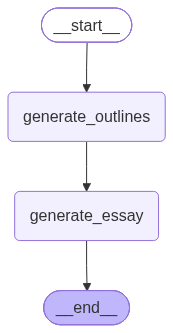

In [25]:
workflow

In [27]:
initial_state = {'topic': 'Agentic AI'}
res = workflow.invoke(initial_state)
res['essay']

'**Agentic AI: The Rise of Autonomous Artificial Intelligence**\n\nArtificial intelligence has advanced rapidly over the past few decades, moving from simple rule-based systems to highly capable machines that can analyze data, recognize patterns, and generate content. One of the most exciting developments in this field is **Agentic AI**, a form of artificial intelligence designed to act independently, make decisions, and pursue goals with minimal human input. Unlike older AI systems that only respond to direct commands, agentic AI can take initiative, plan actions, and adapt to changing situations. As businesses, schools, hospitals, and industries increasingly rely on digital systems, agentic AI is becoming an important topic because it has the potential to transform how people work and live. At the same time, it raises serious questions about safety, ethics, and control. Agentic AI matters because it represents a major step toward autonomous intelligent systems that can improve effici

In [33]:
# Now we will be using the streaming
# Streaming returns the Python Generator object
initial_state = {'topic': 'PM of India'}
for message, metadata in workflow.stream(input=initial_state, stream_mode='messages'):
    if(message.content):
        print(message.content, end="", flush=True)

Sure — here’s a clear outline you can use for an essay on **“The Prime Minister of India”**.

## Outline

### 1. Introduction
- Brief introduction to the Prime Minister of India
- Mention that the Prime Minister is the head of government
- Explain that the PM plays an important role in running the country

### 2. Appointment of the Prime Minister
- The President of India appoints the Prime Minister
- Usually, the leader of the majority party or coalition in the Lok Sabha becomes PM
- Importance of winning public support in elections

### 3. Powers and Functions
- Leads the Council of Ministers
- Advises the President
- Makes important policy decisions
- Represents India in national and international matters
- Oversees the work of different ministries

### 4. Importance of the Prime Minister
- Central figure in the Indian government
- Helps in maintaining stability and leadership
- Guides development and administration
- Acts as a link between the President and the Cabinet

### 5. Quali